# Actor-Critic Agents

Ahora trabajaremos con los algoritmos de gradiente de política: Advantage Actor-Critic (A2C) y Soft Actor-Critic (SAC). Estudiaremos ambos algoritmos usando las implementaciones incluidas dentro de <a href="https://stable-baselines3.readthedocs.io/en/master/index.html">Stable Baselines3</a>, y los usaremos para resolver dos problemas de robótica basados en el entorno de simulación MuJoCo: <a href="https://gymnasium.farama.org/environments/mujoco/hopper/">Hopper</a> y <a href="https://gymnasium.farama.org/environments/mujoco/ant/">Ant</a>. 


# Instalación de Librerías  

Antes de comenzar, se sugiere elegir un entorno de simulación acelerado por GPU. En el caso de Colab gratuito, debería elegir el entorno de T4. Para ello diríjase a:

`Entorno de Ejecución > Cambiar Tipo de Entorno de Ejecución > GPU T4`


![DobleDQNdF](runtime.png)


Después, ejecute el siguiente bloque de código para instalar todas las librerías y herramientas necesarias.


Corra el siguiente bloque de código para instalar las librerías requeridas en el tutorial. Se encuentra incluído el módulo oficial de Stable Baselines3 que ejecuta A2C y SAC, y los ambientes de Gymnasium que incluyen Hopper y Ant. Esta celda puede tardar un par de minutos en ejecutarse completamente la primera vez.


In [ ]:
# Instalación de dependencias del sistema
!apt update -y > /dev/null
!apt install -y xvfb ffmpeg > /dev/null

# Instalación de paquetes de Python
!pip install gymnasium[mujoco] -q
!pip install pyvirtualdisplay
!pip install stable_baselines3 #Stable Baselines3 -> Framework de Reinforcement Learning
!pip install imageio[ffmpeg]

In [ ]:

# Importación de librerías necesarias
from pyvirtualdisplay import Display
from IPython.display import HTML
from base64 import b64encode

import gymnasium as gym
import imageio
import torch
import numpy as np
import matplotlib.pyplot as plt
import os
import time

from stable_baselines3 import SAC, A2C
from stable_baselines3.common.env_util import make_vec_env
from stable_baselines3.common.callbacks import BaseCallback


#Limpia los registros generados
from IPython.display import clear_output
clear_output()
print("Todas las librerías han sido instaladas correctamente.")

Todas las librerías han sido instaladas correctamente.


# Familiarización con los Entornos de Gym

Los siguientes ambientes de Gymnasium son entornos basados en MuJoCo de Google Deep Mind. MuJoCo (Multi-Joint dynamics with Contact) es un simulador físico utilizado para modelar y estudiar el comportamiento de sistemas dinámicos complejos, muy utilizado en robótica.

  



## Inverted Pendulum

El ambiente de <a href="https://gymnasium.farama.org/environments/mujoco/inverted_pendulum/">Inverted Pendulum</a> corresponde al ambiente de Cartpole, basado en el trabajo de Barto, Sutton y Anderson en “Neuronlike adaptive elements that can solve difficult learning control problems”, al igual que en los ambientes clásicos, pero ahora impulsado por el simulador físico MuJoCo, lo que permite experimentos más complejos (como variar los efectos de la gravedad). Este ambiente consiste en un carro que puede moverse linealmente, con un péndulo unido a un extremo y el otro extremo libre. El carro puede ser empujado hacia la izquierda o la derecha, y el objetivo es equilibrar el péndulo sobre el carro aplicando fuerzas al mismo.

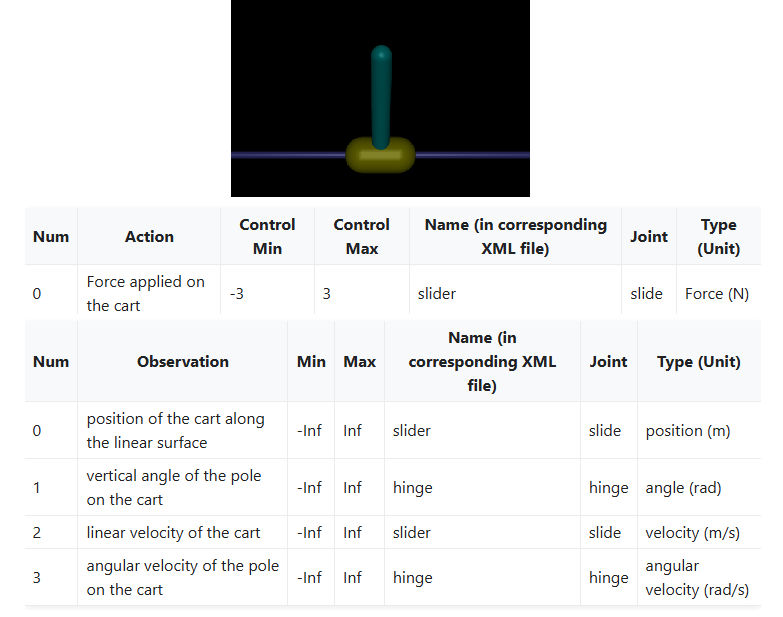

<center>Figura 1. Descripción del ambiente de Inverted Pendulum. [4]</center>

Como se puedes ver en la Figura 1, el espacio de acciones de este entorno es continuo y consiste en un vector de una dimensión con valores entre -3 y 3. Esta acción representa la fuerza aplicada al carro: su magnitud indica la intensidad y su signo la dirección (positiva hacia la derecha, negativa hacia la izquierda). El espacio de observación está compuesto por cuatro valores: la posición del carro, el ángulo del péndulo respecto a la vertical, la velocidad lineal del carro y la velocidad angular del péndulo. Cada uno de estos valores puede tomar cualquier número real. En cuanto a las recompensas, el agente recibe +1 por cada paso de tiempo en el que el péndulo se mantiene en posición vertical, es decir, dentro de un ángulo menor a 0.2 radianes respecto a la vertical. El objetivo es maximizar esta recompensa manteniendo el equilibrio del péndulo el mayor tiempo posible.

### Ejemplo

En el siguiente bloque de código se muestra un ejemplo de cómo se simula un episodio del CartPole. En este caso siempre se toma la acción de ir a la derecha con una fuerza de 0.05 N.

In [2]:
# Start a virtual display (needed in Colab or headless)
display = Display(visible=0, size=(1400, 900))
display.start()

# Create Hopper environment with RGB rendering
env = gym.make("InvertedPendulum-v5", render_mode="rgb_array")
obs, info = env.reset()

frames = []
terminated = truncated = False
total_reward = 0

while not (terminated or truncated):
    action = [0.05]
    obs, reward, terminated, truncated, info = env.step(action)
    frame = env.render()
    frames.append(frame)
    total_reward += reward

env.close()

# Save video
imageio.mimsave("ip_video_rigth.mp4", frames, fps=30)
print("Total reward:", total_reward)

Total reward: 14


In [4]:
mp4 = open("ip_video_rigth.mp4", "rb").read()
data_url = "data:video/mp4;base64," + b64encode(mp4).decode()

HTML(f"""
<video width=600 controls>
    <source src="{data_url}" type="video/mp4">
</video>
""")

 ### Ejercicio práctico 1


Para comprobar el entendimiento de la simulación, modifique el ejemplo anterior cambiando la acción. Simule el ambiente donde la acción se escoja aleatoriamente entre izquierda y derecha, con una fuerza dentro del rango posible, (recuerde utilizar la función reset() antes de comenzar un nuevo episodio).

In [ ]:
# Completar--------------------------------------------------------------------------

In [ ]:
# Completar--------------------------------------------------------------------------

## Inverted Double Pendulum

El ambiente de <a href="https://gymnasium.farama.org/environments/mujoco/inverted_double_pendulum/">Inverted Double Pendulum</a>  consiste en un carro que puede moverse linealmente, con un primer péndulo unido a él y un segundo péndulo conectado al extremo libre del primero (dejando al segundo péndulo con un extremo libre). El carro puede ser empujado hacia la izquierda o la derecha, y el objetivo es equilibrar el segundo péndulo sobre el primero, que a su vez está sobre el carro, aplicando fuerzas continuas al carro.

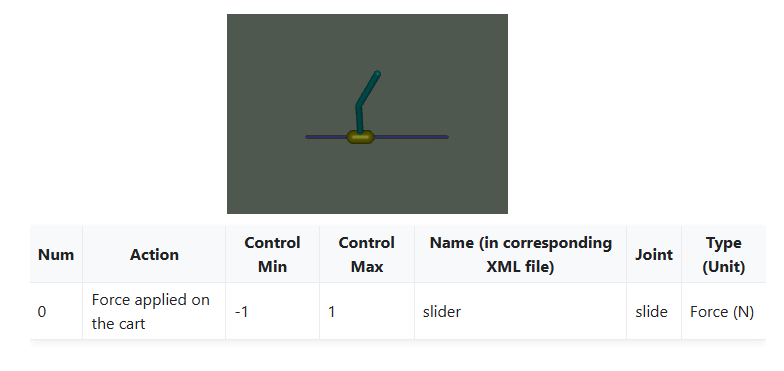

<center>Figura 2. Descripción del ambiente de Inverted Double Pendulum. [5]</center>

El espacio de acciones de este ambiente es continuo y está representado por un vector unidimensional con valores entre -1 y 1. Esta acción corresponde a la fuerza aplicada al carro, donde la magnitud indica la intensidad y el signo la dirección (positiva hacia la derecha, negativa hacia la izquierda). El espacio de observaciones está compuesto por 9 elementos: la posición del carro, el seno y coseno de los ángulos de los dos péndulos, las velocidades lineales y angulares de las partes móviles, y una fuerza de restricción aplicada por el simulador. Estos valores permiten al agente percibir el estado completo del sistema físico. En cuanto a las recompensas, el agente recibe una recompensa positiva constante por cada paso en el que logra mantener el segundo péndulo en equilibrio sobre el primero, incentivando así el aprendizaje de una política que maximice la estabilidad del sistema durante el mayor tiempo posible.

### Ejemplo

En el siguiente bloque de código se muestra un ejemplo de cómo se simula un episodio de DoublePendulum. En este caso siempre se toma la acción de ir a la derecha con una fuerza de 0.05 N.

In [ ]:
# Start a virtual display (needed in Colab or headless)
display = Display(visible=0, size=(1400, 900))
display.start()

# Create Hopper environment with RGB rendering
env = gym.make("InvertedDoublePendulum-v5", render_mode="rgb_array")
obs, info = env.reset()

frames = []
terminated = truncated = False
total_reward = 0

while not (terminated or truncated):
    action = [0.05]
    obs, reward, terminated, truncated, info = env.step(action)
    frame = env.render()
    frames.append(frame)
    total_reward += reward

env.close()

# Save video
imageio.mimsave("idp_video_rigth.mp4", frames, fps=30)
print("Total reward:", total_reward)

In [ ]:
mp4 = open("/content/idp_video_rigth.mp4", "rb").read()
data_url = "data:video/mp4;base64," + b64encode(mp4).decode()

HTML(f"""
<video width=600 controls>
    <source src="{data_url}" type="video/mp4">
</video>
""")

### Ejercicio práctico 2


Para comprobar el entendimiento de la simulación, modifique el ejemplo anterior cambiando la acción. Simule el ambiente donde la acción se escoja aleatoriamente entre izquierda y derecha, con una fuerza dentro del rango posible, (recuerde utilizar la función reset() antes de comenzar un nuevo episodio).

In [ ]:
# Completar--------------------------------------------------------------------------

In [ ]:
# Completar--------------------------------------------------------------------------

# A2C


Recordemos el funcionamiento de los algoritmos de gradiente de política en el aprendizaje por refuerzo. Estos algoritmos, en lugar de realizar una estimación de la función de valor $Q(s,a)$, estiman directamente una política $\pi(s,a,\theta)$ y la mejoran continuamente mediante un proceso de optimización numérica basada en ascenso de gradiente. Uno de estos algoritmos es REINFORCE, estudiado anteriormente en la Tarea de la Semana 4. En este algoritmo, se podía utilizar un <i>baseline</i> para reducir la varianza del entrenamiento. En este escenario, la actualización de REINFORCE está dada por la Ecuación (1):

$\theta_{t+1} \doteq \theta_t + \alpha (G_t-b(S_t)) \frac{\nabla \pi(A_t | S_t, \theta_t)}{\pi(A_t | S_t, \theta_t)}$ &emsp;&emsp;&emsp;$(1)$ 

Una selección común para este <i>baseline</i> es un estimativo adicional de la función de valor de estado $V(s)$. Cuando se usa una función de valor como <i>baseline</i>, el término $G_t-b(S_t)$ se transforma en un estimativo de la ventaja (<i>advantage</i>) de la acción $A_t$ en el estado $S_t$. El retorno $G_t$ funciona como un estimador de $Q(S_t,A_t)$, y como el <i>baseline</i> es un estimativo de $V(S_t)$, se define la ventaja formalmente como aparece en la Ecuación (2):

$A(S_t,A_t) = Q(S_t,A_t) - V(S_t)$ &emsp;&emsp;&emsp;$(2)$ 

Esta aproximación puede ser vista como una arquitectura actor-crítico, donde la política $\pi$ es el actor que efectúa las acciones, y el <i>baseline</i> es el crítico que evalúa el resultado de dichas acciones. Esta estrategia incorpora un <i>bootstrapping</i> que reduce la varianza al mínimo posible, a costa de introducir un sesgo. La Ecuación (2) sugiere incrementar la probabilidad de las acciones mejor que el promedio, y disminuir la probabilidad de las acciones peores al promedio.

Vale la pena mencionar que el algoritmo Advantage Actor-Critic (A2C) es una versión posterior y sincrónica del algoritmo Asynchronous Advantage Actor-Critic (A3C). En la publicación original [2], A3C es un algoritmo que se formula como una versión asincrónica de un algoritmo actor-crítico, que en lugar de usar <i>experience replay</i>, entrena múltiples agentes en varios hilos de CPU, siendo así una aproximación on-policy más rápida y eficiente computacionalmente. A2C en cambio es la versión síncrona, que no usa agentes en paralelo y puede ser mejor para implementar en GPU. En [2] se muestra que la estimación de la ventaja está dada por la Ecuación (3). En los algoritmos actor-crítico es común utilizar una red neuronal para la estimación de la política y otra red distinta para la estimación de la ventaja, por lo cual se usa la notación $\theta$ para referirse a los parámetros de la red del actor, y $\theta_v$ para la red del crítico.

$A(S_t,A_t, \theta, \theta_v) = \sum_{i=0}^{k-1} \gamma^i R_{t+i} + \gamma^k V(S_{t+k}, \theta_v) - V(s_t, \theta_v)$ &emsp;&emsp;&emsp;$(3)$ 


## Entrenamiento de agentes A2C para Inverted Pendulum

En la siguiente celda de código se encuentra la clase encargada del entrenamiento de agentes para el ambiente de Inverted Pendulum

In [ ]:
# Clase personalizada para registrar las recompensas por episodio durante el entrenamiento
class RewardLoggerCallback(BaseCallback):
    def __init__(self):
        super().__init__()
        self.episode_rewards = []  # Lista para almacenar las recompensas por episodio
        self.episode_reward = 0    # Acumulador de recompensa para el episodio actual

    def _on_step(self) -> bool:
        # Si hay recompensas disponibles en el paso actual, se suman al acumulador
        if "rewards" in self.locals:
            self.episode_reward += self.locals["rewards"][0]
        # Si el episodio ha terminado, se guarda la recompensa acumulada y se reinicia el contador
        if "dones" in self.locals and self.locals["dones"][0]:
            self.episode_rewards.append(self.episode_reward)
            self.episode_reward = 0
        return True


# Clase para entrenar un agente en el entorno Inverted Pendulum
class IPTrainer:
    def __init__(self, model_fn, total_timesteps=130_000, log_dir="./IP_logs"):
        self.total_timesteps = total_timesteps
        self.log_dir = log_dir
        os.makedirs(log_dir, exist_ok=True)  # Crear el directorio de logs si no existe

        # Iniciar una pantalla virtual (necesaria en Colab o entornos sin interfaz gráfica)
        self.display = Display(visible=0, size=(1400, 900))
        self.display.start()

        # Crear el entorno Inverted Pendulum vectorizado
        self.env = make_vec_env("InvertedPendulum-v5", n_envs=1)

        # Crear el modelo usando la función proporcionada
        self.model = model_fn(self.env)

        # Inicializar el callback para registrar recompensas
        self.callback = RewardLoggerCallback()


    def train(self, save_path="a2c_ip_model"):
        print("GPU available?", torch.cuda.is_available())
        if torch.cuda.is_available():
            print("Using device:", torch.cuda.get_device_name(0))

        start_time = time.time()
        # Entrenar el modelo con el número total de pasos y el callback
        self.model.learn(total_timesteps=self.total_timesteps, callback=self.callback)
        elapsed = time.time() - start_time

        # Guardar el modelo entrenado
        self.model.save(save_path)
        print(f"Training complete. Model saved. Training took {elapsed:.2f} seconds.")

    def plot_rewards(self):
        # Verificar si hay datos de recompensa para graficar
        if not self.callback.episode_rewards:
            print("No reward data to plot.")
            return
        # Graficar las recompensas por episodio
        plt.figure(figsize=(10, 5))
        plt.plot(self.callback.episode_rewards, label="Episode Reward")
        plt.xlabel("Episodes")
        plt.ylabel("Reward")
        plt.title("Training Rewards Over Time")
        plt.grid()
        plt.legend()
        plt.tight_layout()
        plt.show()

    def generate_video(self, model, video_filename="hopper_video.mp4"):
        # Crear entorno Inverted Double Pendulum con renderizado RGB
        env = gym.make("InvertedPendulum-v5", render_mode="rgb_array")
        obs, info = env.reset()
        frames = []
        total_reward = 0
        terminated = truncated = False

        # Ejecutar el entorno hasta que termine
        while not (terminated or truncated):
            action, _ = model.predict(obs, deterministic=True)  # Predecir acción
            obs, reward, terminated, truncated, info = env.step(action)
            frame = env.render()  # Capturar fotograma
            frames.append(frame)
            total_reward += reward

        env.close()

        # Guardar el video como archivo MP4
        imageio.mimsave(video_filename, frames, fps=30)
        print("Total reward:", total_reward)

        # Mostrar el video en Colab
        mp4 = open(video_filename, "rb").read()
        data_url = "data:video/mp4;base64," + b64encode(mp4).decode()

        return HTML(f"""
        <video width=600 controls>
            <source src="{data_url}" type="video/mp4">
        </video>
        """)


## Ejemplo

En la siguiente celda se muestra el entrenamiento y los resultados para un agente A2C durante 100000 interacciones con el ambiente

In [ ]:
def create_model(env):
    return A2C(
        "MlpPolicy",
        env,
        verbose=1,
        device="cuda"
    )

trainer = IPTrainer(model_fn=create_model, total_timesteps=100_000)
trainer.train(save_path="a2c_ip_model")

In [ ]:
trainer.plot_rewards()
model = A2C.load("a2c_ip_model")
trainer.generate_video(model,video_filename='a2c_ip_video.mp4')

## Ejercicio práctico 3

Reduzca la tasa de aprendizaje y aumente el n_steps para obtener un aprendizaje más estable para el modelo A2C

In [ ]:
def create_model(env):
    return A2C(
# Completar--------------------------------------------------------------------------
    )

trainer = IPTrainer(model_fn=create_model, total_timesteps=)
trainer.train(save_path="a2c_ip_model1")

In [ ]:
trainer.plot_rewards()
model = A2C.load("a2c_ip_model1")
trainer.generate_video(model,video_filename='a2c_ip_video1.mp4')

## Ejercicio Practico 4

Realice el entrenamiento de un modelo A2C para el ambiente de Inverted Double Pendulum (tenga en cuenta que A2C corre mejor en GPU)

In [ ]:
def create_model(env):
    return A2C(
# Completar--------------------------------------------------------------------------
    )

trainer = IDPTrainer(model_fn=create_model, total_timesteps=)
trainer.train(save_path="a2c_idp_model")

In [ ]:
trainer.plot_rewards()
model = A2C.load("a2c_idp_model")
trainer.generate_video(model,video_filename='a2c_idp_video.mp4')

# SAC

El algoritmo Soft Actor-Critic (SAC) es un método de aprendizaje por refuerzo que intenta solucionar problemas de otros algoritmos como la complejidad de muestreo, malas propiedades de convergencia, y el requerimiento de un ajuste fino de hiperparámetros. Adicionalmente, SAC es un algoritmo que no busca únicamente maximizar la recompensa, sino que también busca maximizar la entropía. Para comprender mejor este algoritmo, primero se explicará este concepto de entropía y el concepto detrás de <i>Soft Policy Iteration</i>.

Como se mencionó anteriormente, SAC sigue el principio de máxima entropía, lo cual quiere decir que no solo se busca maximizar la recompensa, sino también la entropía de la política. Esto se expresa en la Ecuación (4). En este escenario, $R(S_t,A_t)$, $\mathcal{H}(\pi(\cdot|S_t))$ es la entropía de la política y $\alpha$ es un coeficiente (llamado temperatura) que controla cuánto se valora la entropía (exploración) frente a la recompensa. La entropía en aprendizaje por refuerzo dimensiona cuán impredecible o aleatoria es una política, y una política estocástica con alta entropía explora más. Aumentar la entropía incrementa la exploración, mientras que disminuir la entropía favorece la explotación. La ventaja de esta metodología es que el agente puede alcanzar un comportamiento más robusto que no se estanque en soluciones subóptimas. El proceso de <i>Soft Policy Iteration</i> se refiere al proceso de actualizar la política que regulariza la entropía y también premia la exploración de acciones.  

$ J(\pi) = \sum_{t=0}^{\infty} \mathbb{E}_{(s_t, a_t) \sim \rho_\pi} \left[ r(s_t, a_t) + \alpha \mathcal{H}(\pi(\cdot | s_t)) \right] $ &emsp;&emsp;&emsp;$(4)$ 

En la implementación, SAC generalmente utiliza una política Gaussiana para el actor, y para el crítico utiliza Doble Q-Learning, lo cual implica dos redes neuronales adicionales, lo cual puede ser más costoso computacionalmente, pero da mejores resultados al mitigar los sesgos de maximización. SAC se caracteriza por ser un algoritmo <i>off-policy</i> robusto, y es el estado del arte en muchos problemas de robótica, superando en muchos escenarios a otros algoritmos como Proximal Policy Optimization (PPO) y Deep Deterministic Policy Gradient (DDPG).

## Ejercicio Práctico 5

Realice el entrenamiento de un modelo SAC para el ambiente de Inverted Pendulum (tenga en cuenta que SAC corre mejor en CPU)

In [ ]:
def create_model(env):
    return SAC(
# Completar--------------------------------------------------------------------------
    )

trainer = IPTrainer(model_fn=create_model, total_timesteps=)
trainer.train(save_path="sac_ip_model")

In [ ]:
trainer.plot_rewards()
model = SAC.load("sac_ip_model")
trainer.generate_video(model,video_filename='sac_ip_video.mp4')

# Entrenamiento de agentes SAC para Inverted Pendulum

En la siguiente celda de código se encuentra la clase encargada del entrenamiento de agentes para el ambiente de Inverted Double Pendulum

In [ ]:
# Clase para entrenar un agente en el entorno Inverted Double Pendulum
class IDPTrainer:
    def __init__(self, model_fn, total_timesteps=130_000, log_dir="./IP_logs"):
        self.total_timesteps = total_timesteps
        self.log_dir = log_dir
        os.makedirs(log_dir, exist_ok=True)  # Crear el directorio de logs si no existe

        # Iniciar una pantalla virtual (necesaria en Colab o entornos sin interfaz gráfica)
        self.display = Display(visible=0, size=(1400, 900))
        self.display.start()

        # Crear el entorno Inverted Double Pendulum vectorizado
        self.env = make_vec_env("InvertedDoublePendulum-v5", n_envs=1)

        # Crear el modelo usando la función proporcionada
        self.model = model_fn(self.env)

        # Inicializar el callback para registrar recompensas
        self.callback = RewardLoggerCallback()


    def train(self, save_path="a2c_ip_model"):
        print("GPU available?", torch.cuda.is_available())
        if torch.cuda.is_available():
            print("Using device:", torch.cuda.get_device_name(0))

        start_time = time.time()
        # Entrenar el modelo con el número total de pasos y el callback
        self.model.learn(total_timesteps=self.total_timesteps, callback=self.callback)
        elapsed = time.time() - start_time

        # Guardar el modelo entrenado
        self.model.save(save_path)
        print(f"Training complete. Model saved. Training took {elapsed:.2f} seconds.")

    def plot_rewards(self):
        # Verificar si hay datos de recompensa para graficar
        if not self.callback.episode_rewards:
            print("No reward data to plot.")
            return
        # Graficar las recompensas por episodio
        plt.figure(figsize=(10, 5))
        plt.plot(self.callback.episode_rewards, label="Episode Reward")
        plt.xlabel("Episodes")
        plt.ylabel("Reward")
        plt.title("Training Rewards Over Time")
        plt.grid()
        plt.legend()
        plt.tight_layout()
        plt.show()

    def generate_video(self, model, video_filename="hopper_video.mp4"):
        # Crear entorno Inverted Double Pendulum con renderizado RGB
        env = gym.make("InvertedDoublePendulum-v5", render_mode="rgb_array")
        obs, info = env.reset()
        frames = []
        total_reward = 0
        terminated = truncated = False

        # Ejecutar el entorno hasta que termine
        while not (terminated or truncated):
            action, _ = model.predict(obs, deterministic=True)  # Predecir acción
            obs, reward, terminated, truncated, info = env.step(action)
            frame = env.render()  # Capturar fotograma
            frames.append(frame)
            total_reward += reward

        env.close()

        # Guardar el video como archivo MP4
        imageio.mimsave(video_filename, frames, fps=30)
        print("Total reward:", total_reward)

        # Mostrar el video en Colab
        mp4 = open(video_filename, "rb").read()
        data_url = "data:video/mp4;base64," + b64encode(mp4).decode()

        return HTML(f"""
        <video width=600 controls>
            <source src="{data_url}" type="video/mp4">
        </video>
        """)


## Ejemplo

En la siguiente celda se muestra el entrenamiento y los resultados para un agente SAC durante 10000 interacciones con el ambiente

In [ ]:
def create_model(env):
    return SAC(
        "MlpPolicy",
        env,
        verbose=1,
        device="cpu"
    )

trainer = IDPTrainer(model_fn=create_model, total_timesteps=10_000)
trainer.train(save_path="sac_idp_model")

In [ ]:
trainer.plot_rewards()
model = SAC.load("sac_idp_model")
trainer.generate_video(model,video_filename='sac_idp_video.mp4')

## Ejecicio Práctico 6

Reduzca la tasa de aprendizaje y aumente el n_steps para obtener un aprendizaje más estable para el modelo SAC

In [ ]:
def create_model(env):
    return SAC(
# Completar--------------------------------------------------------------------------
    )

trainer = IDPTrainer(model_fn=create_model, total_timesteps=)
trainer.train(save_path="a2c_idp_model1")

In [ ]:
trainer.plot_rewards()
model = SAC.load("sac_idp_model1")
trainer.generate_video(model,video_filename='sac_idp_video1.mp4')

# Reflexiones Finales

Teniendo en cuenta los resultados observado en ambos ambientes con A2C sin hiperparámetros ajustados, con hiperparámetros ajustados y con SAC, reflexione sobre las siguientes preguntas:


*   ¿Qué algoritmo es más robusto? ¿A qué puede deberse?

*   ¿Qué algoritmo es más costoso computacionalmente? ¿A qué puede deberse?

*   ¿Qué algoritmo obtiene mejores resultados?

*   ¿Resultó útil el ajuste de hiperparámetros?


# Referencias

[1] Sutton, R. S. and Barto, A. G. (2018). Reinforcement Learning: An Introduction. The MIT Press, second edition.

[2] Mnih, V., Puigdomènech, A., Mirza, M., Graves A., Lillicrap T., Harley, T., Silver, D. and Kavukcuoglu, K. (2016). Asynchronous Methods for Deep Reinforcement Learning. cite arXiv:1602.01783.

[3] Haarnoja, T., Zhou, A., Abbeel, P. and Levine, S. (2018). Soft Actor-Critic: Off-Policy Maximum Entropy Deep Reinforcement Learning with a Stochastic Actor. cite arXiv:1801.01290.

[4] Gym Documentation, Inverted Pendulum. `https://gymnasium.farama.org/environments/mujoco/inverted_pendulum/`

[5] Gym Documentation, Inverted Double Pendulum. `https://gymnasium.farama.org/environments/mujoco/inverted_double_pendulum/`

[6] Stable Baselines3 Documentation, A2C. `https://stable-baselines.readthedocs.io/en/master/modules/a2c.html`

[7] Stable Baselines3 Documentation, SAC. `https://stable-baselines.readthedocs.io/en/master/modules/sac.html`